# Week 1 — AITEX Fabric Image Database: Dataset Understanding

**Project:** Adaptive Fabric Surface Defect Detection and Localization using Classical Texture Descriptors
**Course:** Digital Image Processing

This notebook covers dataset acquisition, structural inspection, fabric and defect type cataloging, ground-truth mask verification, and exploratory data analysis (EDA) of the AITEX Fabric Image Database (AFID). No defect detection method is implemented in this notebook.

This version consolidates dataset loading into reusable functions (used consistently throughout the notebook instead of repeating the same folder-scanning loop), fixes mask loading to always use a single-channel (grayscale) format, and adds a few additional checks (resolution summary, fabric-wise defect area, defect-free filename convention) requested for completeness.

### Mounting the Dataset
Connecting to Google Drive to access the dataset files.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


#### Imports
All libraries used in this notebook are imported once here, instead of being re-imported in every cell.

In [3]:
import os
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

#### Confirming the Project Folder

In [4]:
import os

print(os.listdir('/content/drive/MyDrive/ECE501'))

['archive']


#### Viewing the Archive Contents

In [5]:
dataset_path = '/content/drive/MyDrive/ECE501/archive'

print(os.listdir(dataset_path))

['Mask_images', 'Defect_images', 'NODefect_images']


#### Double-Checking Folder Names
Using `repr()` to rule out hidden characters in folder names before relying on string-based path matching.

In [6]:
import os

dataset_path = '/content/drive/MyDrive/ECE501/archive'

print("Inside archive:")
for item in os.listdir(dataset_path):
    print(repr(item))

Inside archive:
'Mask_images'
'Defect_images'
'NODefect_images'


## Dataset Paths and Loader Functions

#### Defining Paths and Reusable Loading Functions
Dataset paths are defined once here and reused throughout the notebook. Two loader functions are also defined:

- `get_normal_images()` — collects every defect-free image from within the 7 fabric-type sub-folders under `NODefect_images`.
- `get_defect_images()` / `get_mask_files()` — collect defective images and mask files directly, since those folders are flat.

Using these functions instead of repeating the same folder-scanning loop in multiple cells keeps the notebook consistent if the dataset path or folder structure ever changes.

In [7]:
dataset_path = Path('/content/drive/MyDrive/ECE501/archive')

normal_path = dataset_path / 'NODefect_images'
defect_path = dataset_path / 'Defect_images'
mask_path = dataset_path / 'Mask_images'


def get_normal_images(normal_path=normal_path):
    """Return a list of Path objects for every defect-free image,
    collected from the fabric-type sub-folders under NODefect_images."""
    images = []
    for fabric_folder in normal_path.iterdir():
        if fabric_folder.is_dir():
            images.extend(fabric_folder.glob('*.png'))
    return images


def get_defect_images(defect_path=defect_path):
    """Return a list of Path objects for every defective image."""
    return list(defect_path.glob('*.png'))


def get_mask_files(mask_path=mask_path):
    """Return a list of Path objects for every ground-truth mask file."""
    return list(mask_path.glob('*.png'))


normal_images = get_normal_images()
defect_images = get_defect_images()
mask_files = get_mask_files()

print("Normal images   :", len(normal_images))
print("Defective images:", len(defect_images))
print("Mask files      :", len(mask_files))

Normal images   : 141
Defective images: 106
Mask files      : 107


#### Top-Level Folder Counts
Counting entries directly inside each top-level folder. The count for `NODefect_images` reflects the number of fabric-type sub-folders (7), not individual images — the actual image count is shown above.

In [8]:
print("Entries in NODefect_images :", len(os.listdir(normal_path)))
print("Entries in Defect_images  :", len(os.listdir(defect_path)))
print("Entries in Mask_images    :", len(os.listdir(mask_path)))

Entries in NODefect_images : 7
Entries in Defect_images  : 106
Entries in Mask_images    : 107


#### Peeking at Filenames
Printing a few filenames to confirm the naming convention used for defect images and masks.

In [9]:
print("First 10 defect images:")
print([f.name for f in defect_images[:10]])

print("\nFirst 10 mask files:")
print([f.name for f in mask_files[:10]])

First 10 defect images:
['0043_019_04.png', '0041_019_02.png', '0042_019_02.png', '0074_010_03.png', '0060_022_06.png', '0061_022_06.png', '0077_022_03.png', '0086_030_02.png', '0075_010_03.png', '0057_019_06.png']

First 10 mask files:
['0001_002_00_mask.png', '0002_002_00_mask.png', '0012_006_02_mask.png', '0011_006_02_mask.png', '0004_002_01_mask.png', '0010_006_02_mask.png', '0005_002_01_mask.png', '0015_006_02_mask.png', '0014_006_02_mask.png', '0013_006_02_mask.png']


#### Verifying File Types by Size
Checking file sizes to catch corrupted or empty files before loading images in bulk. Entries under `NODefect_images` show up as directory-sized (not image-sized) because they are the fabric-type sub-folders.

In [10]:
print("NODefect_images entries:")
for item in Path(normal_path).iterdir():
    print(" ", item.name, "| is_dir:", item.is_dir(), "|", item.stat().st_size, "bytes")

print("\nSample defect image sizes:")
for f in defect_images[:5]:
    print(" ", f.name, "|", f.stat().st_size, "bytes")

print("\nSample mask file sizes:")
for f in mask_files[:5]:
    print(" ", f.name, "|", f.stat().st_size, "bytes")

NODefect_images entries:
  2311980-185026u | is_dir: True | 4096 bytes
  2608691-202020u | is_dir: True | 4096 bytes
  2311694-2040n7u | is_dir: True | 4096 bytes
  2306894-210033u | is_dir: True | 4096 bytes
  2306881-210020u | is_dir: True | 4096 bytes
  2311517-195063u | is_dir: True | 4096 bytes
  2311694-1930c7u | is_dir: True | 4096 bytes

Sample defect image sizes:
  0043_019_04.png | 855090 bytes
  0041_019_02.png | 798478 bytes
  0042_019_02.png | 798903 bytes
  0074_010_03.png | 617211 bytes
  0060_022_06.png | 733866 bytes

Sample mask file sizes:
  0001_002_00_mask.png | 3377 bytes
  0002_002_00_mask.png | 3124 bytes
  0012_006_02_mask.png | 3624 bytes
  0011_006_02_mask.png | 4630 bytes
  0004_002_01_mask.png | 3672 bytes


#### Confirming Fabric-Type Sub-Folders
Listing the sub-folders under `NODefect_images` to confirm each one corresponds to a fabric type.

In [11]:
for fabric_folder in sorted(normal_path.iterdir()):
    if fabric_folder.is_dir():
        print(fabric_folder.name, "| is_dir:", fabric_folder.is_dir())

2306881-210020u | is_dir: True
2306894-210033u | is_dir: True
2311517-195063u | is_dir: True
2311694-1930c7u | is_dir: True
2311694-2040n7u | is_dir: True
2311980-185026u | is_dir: True
2608691-202020u | is_dir: True


#### Normal Image Count by Fabric Type

In [12]:
print("Normal images by fabric:\n")

total_normal = 0
for fabric_folder in sorted(normal_path.iterdir()):
    if fabric_folder.is_dir():
        count = len(list(fabric_folder.glob('*.png')))
        total_normal += count
        print(f"{fabric_folder.name}: {count} images")

print("\nTotal normal images:", total_normal)

Normal images by fabric:

2306881-210020u: 20 images
2306894-210033u: 20 images
2311517-195063u: 20 images
2311694-1930c7u: 20 images
2311694-2040n7u: 20 images
2311980-185026u: 20 images
2608691-202020u: 21 images

Total normal images: 141


## Image and Mask Property Verification

#### Loading Sample Images
Loading one normal image and one defective image to check dimensions and color mode.

In [13]:
normal_sample = normal_images[0]
defect_sample = defect_images[0]

normal_img = Image.open(normal_sample)
defect_img = Image.open(defect_sample)

print("Normal image:")
print("Path:", normal_sample)
print("Size:", normal_img.size)
print("Mode:", normal_img.mode)

print("\nDefective image:")
print("Path:", defect_sample)
print("Size:", defect_img.size)
print("Mode:", defect_img.mode)

Normal image:
Path: /content/drive/MyDrive/ECE501/archive/NODefect_images/2311980-185026u/0003_000_06.png
Size: (4096, 256)
Mode: L

Defective image:
Path: /content/drive/MyDrive/ECE501/archive/Defect_images/0043_019_04.png
Size: (4096, 256)
Mode: LA


#### Checking the Mask Format
Loading the mask corresponding to the selected defective image and inspecting its data type and unique pixel values. The mask is explicitly converted to single-channel (`'L'`) grayscale on load, so pixel counts and area calculations later in the notebook are not affected if a mask happens to be stored in a different mode (e.g. RGB).

In [14]:
mask_file = mask_path / f'{defect_sample.stem}_mask.png'

print("Defective image:", defect_sample.name)
print("Expected mask:", mask_file.name)
print("Mask exists:", mask_file.exists())

mask_img = Image.open(mask_file).convert('L')

print("\nMask information:")
print("Size:", mask_img.size)
print("Mode:", mask_img.mode)

mask_array = np.array(mask_img)

print("Data type:", mask_array.dtype)
print("Unique pixel values:", np.unique(mask_array))

Defective image: 0043_019_04.png
Expected mask: 0043_019_04_mask.png
Mask exists: True

Mask information:
Size: (4096, 256)
Mode: L
Data type: uint8
Unique pixel values: [  0 192 196 202 204 211 213 214 219 222 223 225 226 229 231 232 234 236
 237 238 239 240 241 242 244 245 246 247]


#### Displaying Image and Mask Side by Side

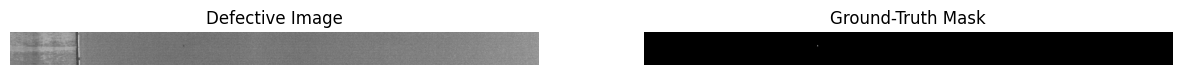

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(defect_img, cmap='gray')
plt.title('Defective Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask_img, cmap='gray')
plt.title('Ground-Truth Mask')
plt.axis('off')

plt.show()

#### Overlaying the Mask on the Image

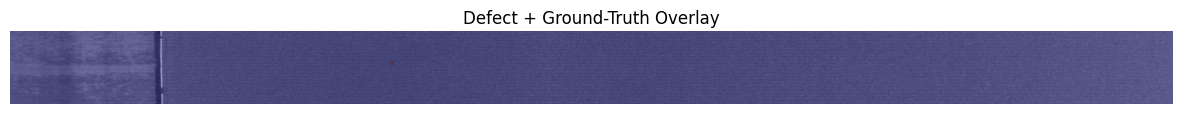

In [16]:
plt.figure(figsize=(15, 5))

plt.imshow(defect_img, cmap='gray')
plt.imshow(mask_img, cmap='jet', alpha=0.4)

plt.title('Defect + Ground-Truth Overlay')
plt.axis('off')

plt.show()

## Image-to-Mask Consistency Check

#### Matching Defect Images to Their Masks
Matching defect image names against mask file names (removing the `_mask` suffix) to confirm a one-to-one correspondence.

In [17]:
from pathlib import Path

dataset_path = Path('/content/drive/MyDrive/ECE501/archive')

defect_path = dataset_path / 'Defect_images'
mask_path = dataset_path / 'Mask_images'

# Get image names without extensions
defect_names = {
    file.stem
    for file in defect_path.glob('*.png')
}

# Get mask names without "_mask.png"
mask_names = {
    file.stem.replace('_mask', '')
    for file in mask_path.glob('*.png')
}

# Find matches and mismatches
matched = defect_names & mask_names
missing_masks = defect_names - mask_names
extra_masks = mask_names - defect_names

print("Defect images:", len(defect_names))
print("Masks:", len(mask_names))
print("Matched pairs:", len(matched))

print("\nDefective images WITHOUT a mask:")
print(sorted(missing_masks))

print("\nMasks WITHOUT a defective image:")
print(sorted(extra_masks))

Defect images: 106
Masks: 107
Matched pairs: 103

Defective images WITHOUT a mask:
['0044_019_04', '0097_030_03', '0100_025_08']

Masks WITHOUT a defective image:
['0044_019_041', '0044_019_042', '0097_030_031', '0097_030_032']


#### Inspecting the Unmatched Cases

In [18]:
from pathlib import Path

mask_path = Path('/content/drive/MyDrive/ECE501/archive/Mask_images')

print("Masks related to 0044:")
for f in sorted(mask_path.glob('0044*')):
    print(f.name)

print("\nMasks related to 0097:")
for f in sorted(mask_path.glob('0097*')):
    print(f.name)

print("\nMasks related to 0100:")
for f in sorted(mask_path.glob('0100*')):
    print(f.name)

Masks related to 0044:
0044_019_04_mask1.png
0044_019_04_mask2.png

Masks related to 0097:
0097_030_03_mask1.png
0097_030_03_mask2.png

Masks related to 0100:


In [19]:
from pathlib import Path

mask_path = Path('/content/drive/MyDrive/ECE501/archive/Mask_images')

print("All masks containing 0100:")
for f in sorted(mask_path.glob('*0100*')):
    print(f.name)

print("\nFirst 30 mask filenames:")
for f in sorted(mask_path.glob('*.png'))[:30]:
    print(f.name)

All masks containing 0100:

First 30 mask filenames:
0001_002_00_mask.png
0002_002_00_mask.png
0003_002_00_mask.png
0004_002_01_mask.png
0005_002_01_mask.png
0006_002_01_mask.png
0010_006_02_mask.png
0011_006_02_mask.png
0012_006_02_mask.png
0013_006_02_mask.png
0014_006_02_mask.png
0015_006_02_mask.png
0016_006_02_mask.png
0017_002_02_mask.png
0018_010_03_mask.png
0019_016_03_mask.png
0020_016_03_mask.png
0021_016_03_mask.png
0022_019_02_mask.png
0023_019_02_mask.png
0024_019_02_mask.png
0025_019_02_mask.png
0026_019_02_mask.png
0027_019_02_mask.png
0028_019_02_mask.png
0029_019_02_mask.png
0030_019_02_mask.png
0031_019_02_mask.png
0032_019_02_mask.png
0033_019_02_mask.png


## Fabric and Defect Type Cataloging

#### Defining Defect Type Codes
AITEX defect type codes and their corresponding names, as defined in the dataset documentation. Each defective image filename encodes an image number, a defect code, and a fabric code (`nnnn_ddd_ff.png`).

In [20]:
defect_codes = {
    2: "Broken end",
    6: "Broken yarn",
    10: "Broken pick",
    16: "Weft curling",
    19: "Fuzzyball",
    22: "Cut selvage",
    23: "Crease",
    25: "Warp ball",
    27: "Knots",
    29: "Contamination",
    30: "Nep",
    36: "Weft crack"
}

for code, name in defect_codes.items():
    print(f"{code:02d} → {name}")

02 → Broken end
06 → Broken yarn
10 → Broken pick
16 → Weft curling
19 → Fuzzyball
22 → Cut selvage
23 → Crease
25 → Warp ball
27 → Knots
29 → Contamination
30 → Nep
36 → Weft crack


#### Parsing a Sample Filename

In [21]:
filename = "0019_016_03.png"

parts = Path(filename).stem.split("_")

image_number = parts[0]
defect_code = int(parts[1])
fabric_code = int(parts[2])

print("Image number :", image_number)
print("Defect code  :", defect_code)
print("Fabric code  :", fabric_code)
print("Defect name  :", defect_codes[defect_code])

Image number : 0019
Defect code  : 16
Fabric code  : 3
Defect name  : Weft curling


#### Counting Images per Defect Type

In [22]:
from collections import Counter

defect_path = Path('/content/drive/MyDrive/ECE501/archive/Defect_images')

defect_counter = Counter()

for image_file in defect_path.glob('*.png'):
    parts = image_file.stem.split("_")

    defect_code = int(parts[1])

    defect_counter[defect_code] += 1

print("Defect distribution:\n")

for code in sorted(defect_counter):
    print(
        f"{code:02d} - "
        f"{defect_codes[code]:<20} : "
        f"{defect_counter[code]}"
    )

Defect distribution:

02 - Broken end           : 9
06 - Broken yarn          : 8
10 - Broken pick          : 10
16 - Weft curling         : 3
19 - Fuzzyball            : 39
22 - Cut selvage          : 9
23 - Crease               : 5
25 - Warp ball            : 6
27 - Knots                : 1
29 - Contamination        : 1
30 - Nep                  : 14
36 - Weft crack           : 1


#### Verifying the Number of Defect Types

In [23]:
all_defect_codes = set()

for image_file in defect_path.glob('*.png'):
    parts = image_file.stem.split("_")
    all_defect_codes.add(int(parts[1]))

print("Defect codes found:")
print(sorted(all_defect_codes))

print("\nNumber of defect types found:", len(all_defect_codes))

Defect codes found:
[2, 6, 10, 16, 19, 22, 23, 25, 27, 29, 30, 36]

Number of defect types found: 12


#### Counting Defective Images per Fabric Type

In [24]:
fabric_counter = Counter()

for image_file in defect_path.glob('*.png'):
    parts = image_file.stem.split("_")

    fabric_code = int(parts[2])

    fabric_counter[fabric_code] += 1

print("Defective images by fabric:\n")

for code in sorted(fabric_counter):
    print(f"Fabric {code:02d}: {fabric_counter[code]} images")

Defective images by fabric:

Fabric 00: 7 images
Fabric 01: 12 images
Fabric 02: 38 images
Fabric 03: 31 images
Fabric 04: 10 images
Fabric 05: 1 images
Fabric 06: 6 images
Fabric 08: 1 images


#### Fabric × Defect Cross-Tabulation

In [25]:
from collections import defaultdict

fabric_defect_counts = defaultdict(Counter)

for image_file in defect_path.glob('*.png'):
    parts = image_file.stem.split("_")

    defect_code = int(parts[1])
    fabric_code = int(parts[2])

    fabric_defect_counts[fabric_code][defect_code] += 1

print("Fabric × Defect distribution\n")

for fabric in sorted(fabric_defect_counts):
    print(f"\nFabric {fabric:02d}")

    for defect in sorted(defect_codes):
        count = fabric_defect_counts[fabric][defect]
        print(f"  {defect:02d} - {defect_codes[defect]:<20}: {count}")

Fabric × Defect distribution


Fabric 00
  02 - Broken end          : 3
  06 - Broken yarn         : 0
  10 - Broken pick         : 0
  16 - Weft curling        : 0
  19 - Fuzzyball           : 0
  22 - Cut selvage         : 4
  23 - Crease              : 0
  25 - Warp ball           : 0
  27 - Knots               : 0
  29 - Contamination       : 0
  30 - Nep                 : 0
  36 - Weft crack          : 0

Fabric 01
  02 - Broken end          : 5
  06 - Broken yarn         : 0
  10 - Broken pick         : 0
  16 - Weft curling        : 0
  19 - Fuzzyball           : 1
  22 - Cut selvage         : 0
  23 - Crease              : 2
  25 - Warp ball           : 0
  27 - Knots               : 0
  29 - Contamination       : 0
  30 - Nep                 : 3
  36 - Weft crack          : 1

Fabric 02
  02 - Broken end          : 1
  06 - Broken yarn         : 7
  10 - Broken pick         : 0
  16 - Weft curling        : 0
  19 - Fuzzyball           : 23
  22 - Cut selvage         : 0
  23 -

#### Visualizing Defect Type Distribution

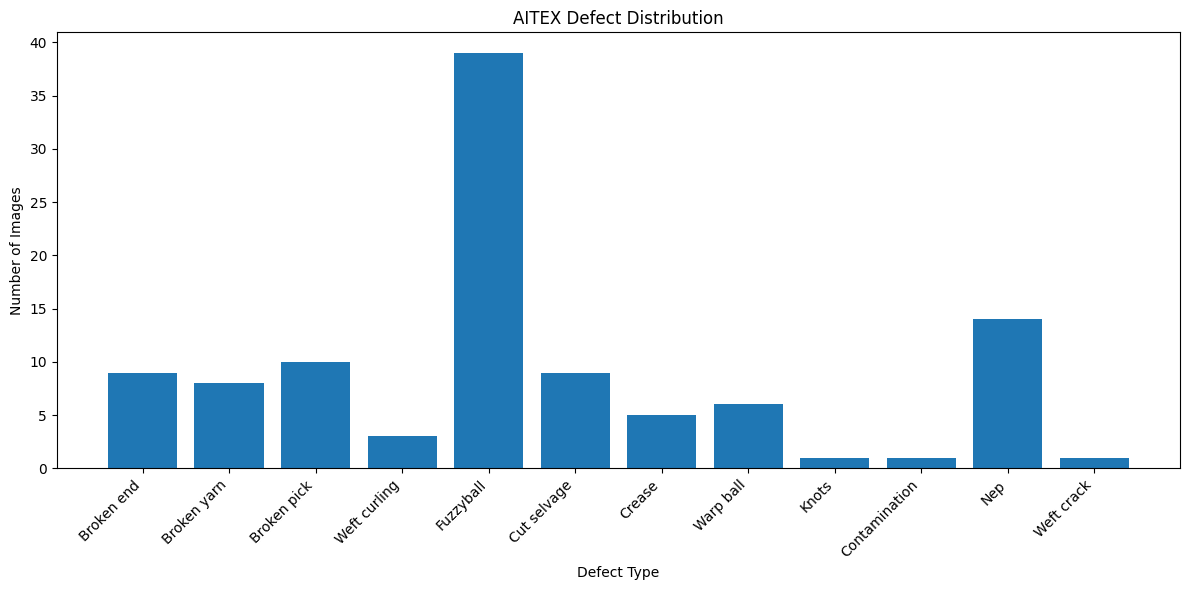

In [26]:
import matplotlib.pyplot as plt

names = [
    defect_codes[code]
    for code in sorted(defect_counter)
]

counts = [
    defect_counter[code]
    for code in sorted(defect_counter)
]

plt.figure(figsize=(12, 6))

plt.bar(names, counts)

plt.xlabel("Defect Type")
plt.ylabel("Number of Images")
plt.title("AITEX Defect Distribution")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Checking the Defect-Free Filename Convention
AITEX documentation states that defect-free images follow the pattern `nnnn_000_ff.png`, with the defect code replaced by `000`. This checks whether that convention is actually present in the filenames under `NODefect_images`, as an alternative way of recovering the fabric code directly from the filename rather than relying on the folder name.

In [27]:
sample_normal_names = [f.name for f in normal_images[:10]]
print("Sample NODefect_images filenames:")
for name in sample_normal_names:
    print(" ", name)

matches_convention = [
    name for name in [f.name for f in normal_images]
    if len(Path(name).stem.split('_')) == 3 and Path(name).stem.split('_')[1] == '000'
]

print(f"\n{len(matches_convention)} of {len(normal_images)} normal image filenames follow the 'nnnn_000_ff.png' convention.")
if not matches_convention:
    print("None of the filenames follow this convention in the current copy of the dataset; "
          "the fabric-type folder name remains the reliable source for fabric grouping of normal images.")

Sample NODefect_images filenames:
  0003_000_06.png
  0001_000_06.png
  0002_000_06.png
  0008_000_06.png
  0020_000_06.png
  0006_000_06.png
  0010_000_06.png
  0007_000_06.png
  0013_000_06.png
  0009_000_06.png

140 of 141 normal image filenames follow the 'nnnn_000_ff.png' convention.


## Visual Exploration of Samples

#### Displaying Normal Image Samples
Displaying a sample of normal (defect-free) images.

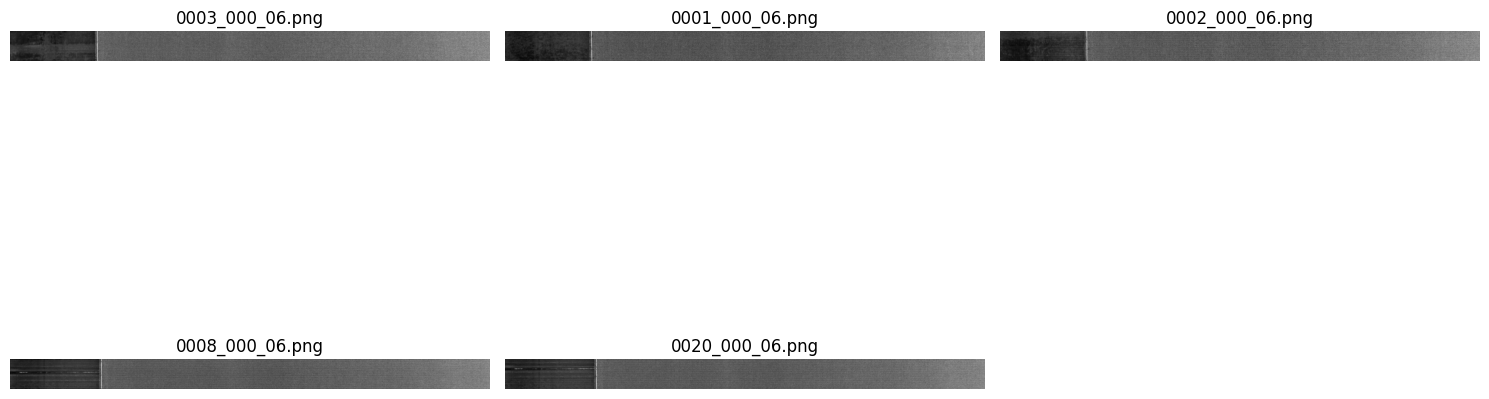

In [28]:
import matplotlib.pyplot as plt
from PIL import Image

# Select first 5 normal images
samples = normal_images[:5]

plt.figure(figsize=(15, 8))

for i, image_path in enumerate(samples):
    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(image_path.name)
    plt.axis('off')

plt.tight_layout()
plt.show()

#### Displaying One Sample per Fabric Type

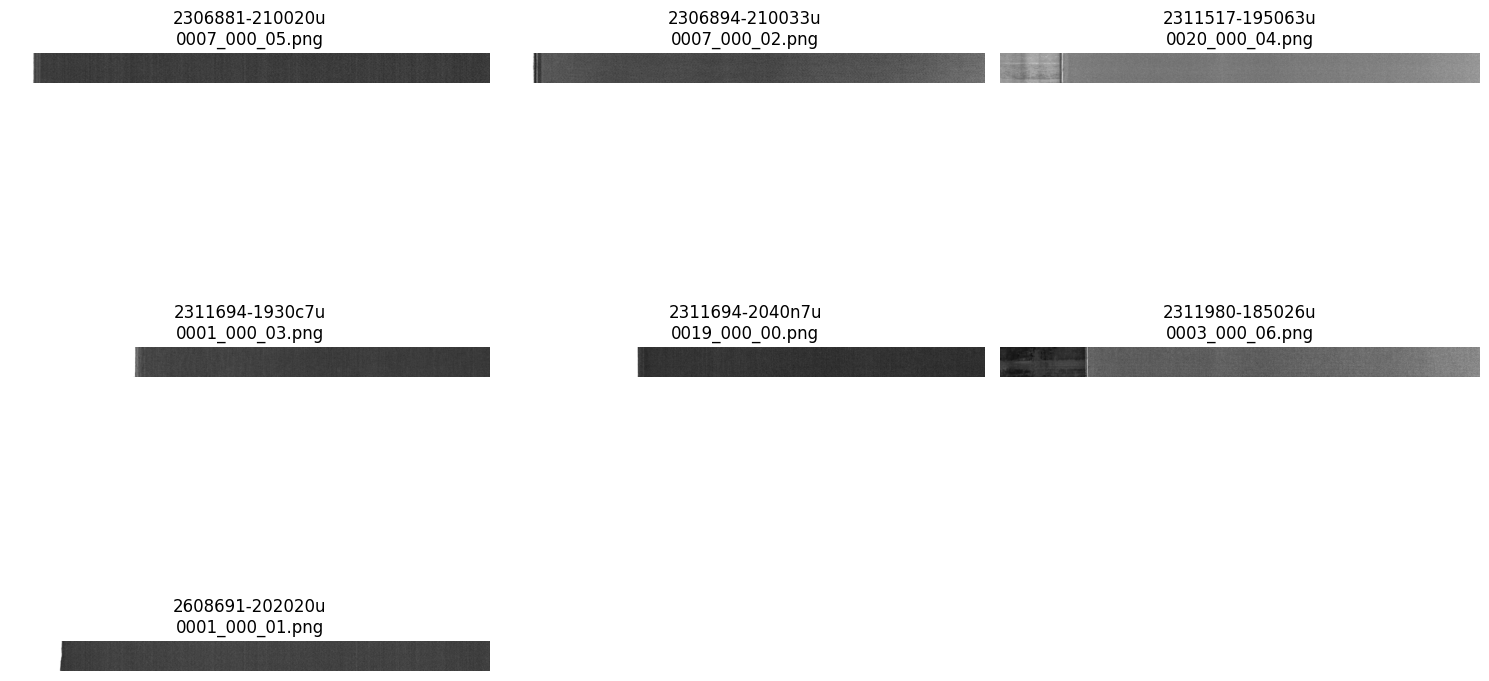

In [29]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

normal_path = Path('/content/drive/MyDrive/ECE501/archive/NODefect_images')

fabric_samples = []

for fabric_folder in sorted(normal_path.iterdir()):
    if fabric_folder.is_dir():
        images = list(fabric_folder.glob('*.png'))

        if len(images) > 0:
            fabric_samples.append((fabric_folder.name, images[0]))

plt.figure(figsize=(15, 10))

for i, (fabric_name, image_path) in enumerate(fabric_samples):

    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f'{fabric_name}\n{image_path.name}')
    plt.axis('off')

plt.tight_layout()
plt.show()

#### Displaying Defective Image Samples

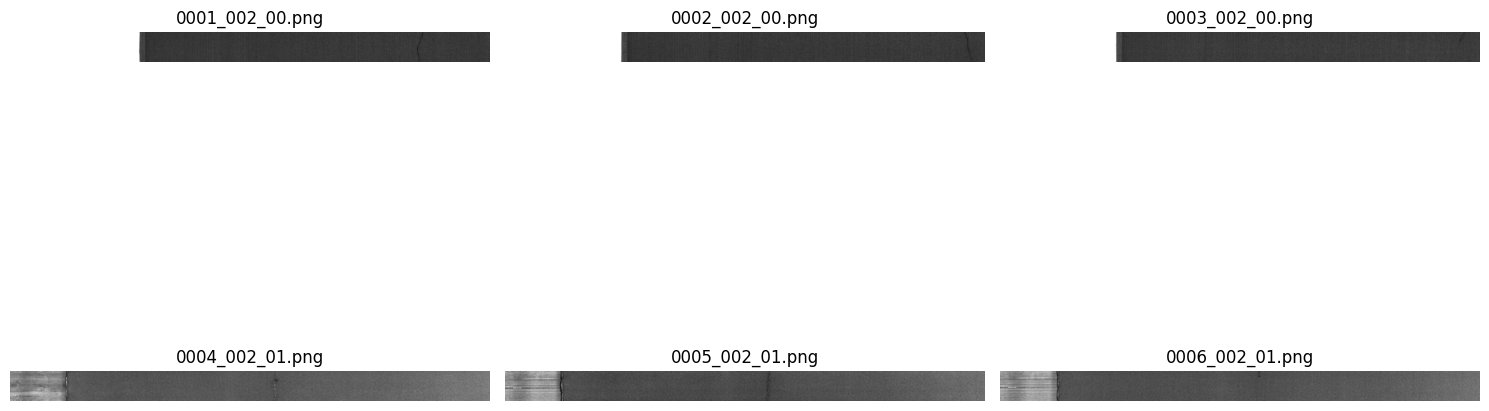

In [30]:
defect_path = Path('/content/drive/MyDrive/ECE501/archive/Defect_images')

defect_samples = sorted(defect_path.glob('*.png'))[:6]

plt.figure(figsize=(15, 10))

for i, image_path in enumerate(defect_samples):

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(image_path.name)
    plt.axis('off')

plt.tight_layout()
plt.show()

#### Displaying a Selected Defective Image and Its Mask

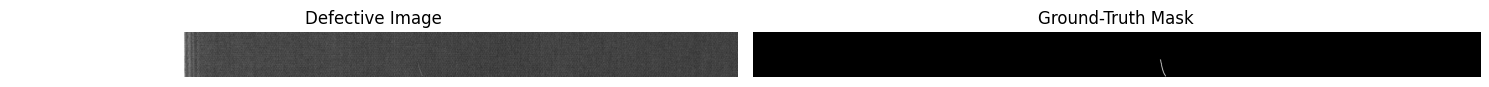

In [31]:
defect_sample = defect_path / '0019_016_03.png'
mask_sample = mask_path / '0019_016_03_mask.png'

defect_img = Image.open(defect_sample)
mask_img = Image.open(mask_sample).convert('L')

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(defect_img, cmap='gray')
plt.title('Defective Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask_img, cmap='gray')
plt.title('Ground-Truth Mask')
plt.axis('off')

plt.tight_layout()
plt.show()

#### Overlaying Mask on the Selected Image

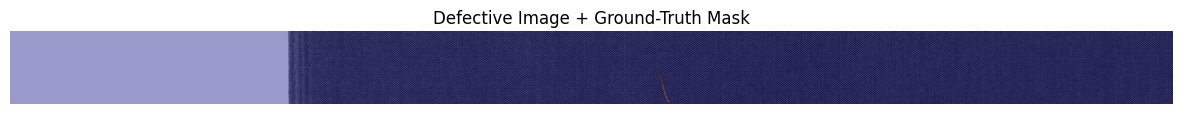

In [32]:
plt.figure(figsize=(15, 5))

plt.imshow(defect_img, cmap='gray')
plt.imshow(mask_img, cmap='jet', alpha=0.4)

plt.title('Defective Image + Ground-Truth Mask')
plt.axis('off')

plt.show()

## Defect Localization from the Mask

#### Computing the Defect Bounding Box
Computing the bounding box of the defect region directly from the non-zero pixels in the mask.

In [33]:
import numpy as np

mask_array = np.array(mask_img)

# Find pixels belonging to the defect
ys, xs = np.where(mask_array > 0)

print("Defect pixel count:", len(xs))

if len(xs) > 0:

    # Bounding box
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()

    print("Bounding box:")
    print("x:", x_min, "to", x_max)
    print("y:", y_min, "to", y_max)

Defect pixel count: 436
Bounding box:
x: 2290 to 2322
y: 158 to 252


#### Cropping to the Defect Region

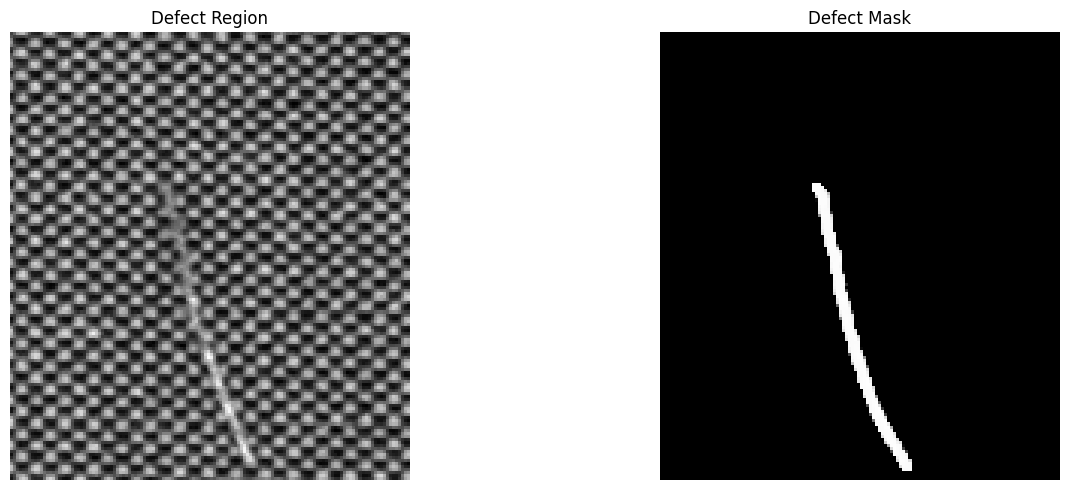

In [34]:
if len(xs) > 0:

    # Add some padding
    padding = 50

    x1 = max(0, x_min - padding)
    x2 = min(defect_img.width, x_max + padding)

    y1 = max(0, y_min - padding)
    y2 = min(defect_img.height, y_max + padding)

    defect_crop = defect_img.crop((x1, y1, x2, y2))
    mask_crop = mask_img.crop((x1, y1, x2, y2))

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(defect_crop, cmap='gray')
    plt.title('Defect Region')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mask_crop, cmap='gray')
    plt.title('Defect Mask')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

#### Re-checking Mask Properties

In [35]:
import numpy as np

mask_array = np.array(mask_img)

print("Mask datatype:", mask_array.dtype)
print("Mask shape:", mask_array.shape)
print("Unique mask values:", np.unique(mask_array))

Mask datatype: uint8
Mask shape: (256, 4096)
Unique mask values: [  0  10  31  41  52  62  73  84  95 106 118 129 141 164 175 188 199 211
 212 213 214 215 216 217 218 219 220 221 222 223 224 226 228 229 230 231
 232 233 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250
 251 252]


#### Calculating Defect Area Percentage

In [36]:
total_pixels = mask_array.size
defect_pixels = np.count_nonzero(mask_array)

defect_percentage = (defect_pixels / total_pixels) * 100

print("Total pixels:", total_pixels)
print("Defect pixels:", defect_pixels)
print("Defect area percentage:", defect_percentage)

Total pixels: 1048576
Defect pixels: 436
Defect area percentage: 0.0415802001953125


## Representative Examples per Defect Type

#### Selecting One Example per Defect Type

In [37]:
from collections import defaultdict

defect_examples = {}

for image_file in sorted(defect_path.glob('*.png')):

    parts = image_file.stem.split('_')
    defect_code = int(parts[1])

    if defect_code not in defect_examples:
        defect_examples[defect_code] = image_file

print("One example per defect:")

for code in sorted(defect_examples):
    print(
        f"{code:02d} - "
        f"{defect_codes[code]} - "
        f"{defect_examples[code].name}"
    )

One example per defect:
02 - Broken end - 0001_002_00.png
06 - Broken yarn - 0010_006_02.png
10 - Broken pick - 0018_010_03.png
16 - Weft curling - 0019_016_03.png
19 - Fuzzyball - 0022_019_02.png
22 - Cut selvage - 0060_022_06.png
23 - Crease - 0066_023_01.png
25 - Warp ball - 0078_025_03.png
27 - Knots - 0094_027_05.png
29 - Contamination - 0083_029_04.png
30 - Nep - 0049_030_03.png
36 - Weft crack - 0080_036_01.png


#### Displaying Defect Type Examples

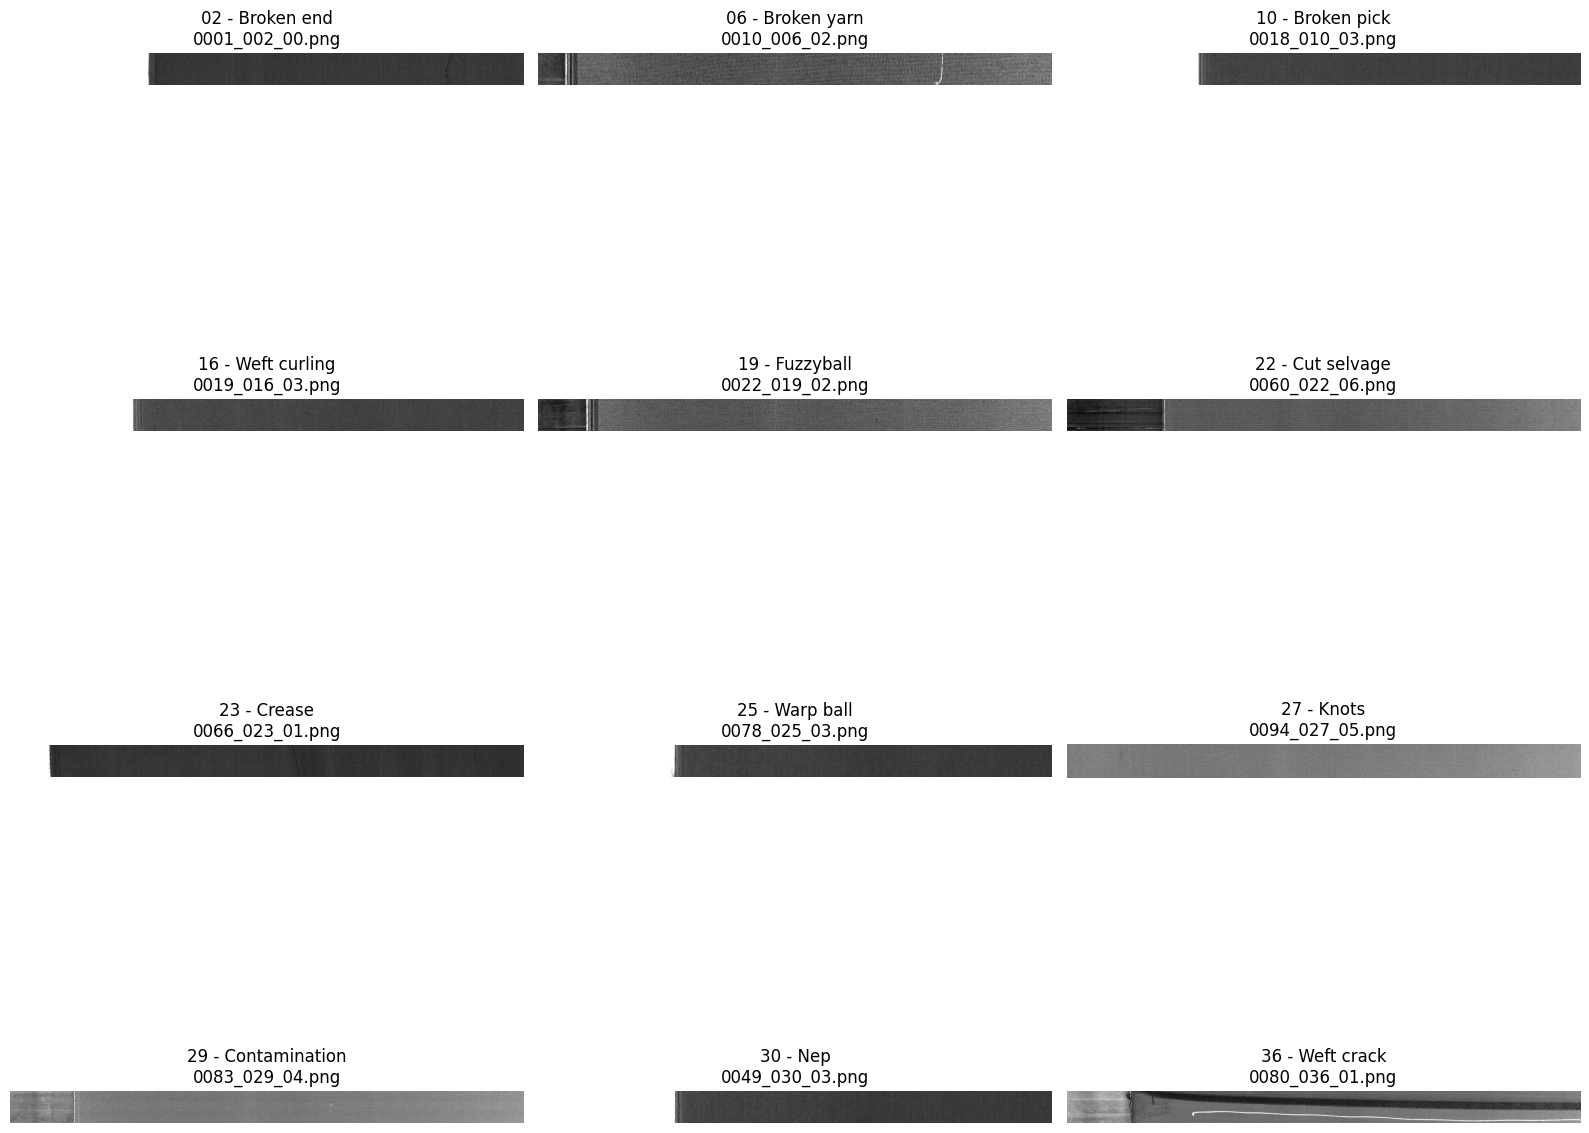

In [38]:
plt.figure(figsize=(16, 16))

for i, code in enumerate(sorted(defect_examples)):

    image_path = defect_examples[code]
    image = Image.open(image_path)

    plt.subplot(4, 3, i + 1)
    plt.imshow(image, cmap='gray')

    plt.title(
        f"{code:02d} - {defect_codes[code]}\n"
        f"{image_path.name}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

## Reusable Visualization Functions

#### Defining Load and Display Functions
Instead of one combined plotting function, loading and displaying are split into separate, single-purpose functions, each with a docstring:

- `load_image(path)` / `load_mask(path)` — load an image or mask from disk (masks are always converted to grayscale).
- `show_image(image)` — display a single image.
- `show_mask(image, mask)` — display an image and its mask side by side.
- `show_overlay(image, mask)` — display the mask overlaid on the image.

In [39]:
def load_image(path):
    """Load a fabric image from disk as a PIL Image."""
    return Image.open(path)


def load_mask(path):
    """Load a ground-truth mask from disk as a single-channel (grayscale) PIL Image."""
    return Image.open(path).convert('L')


def show_image(image, title='Image'):
    """Display a single image."""
    plt.figure(figsize=(8, 4))
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()


def show_mask(image, mask):
    """Display an image and its ground-truth mask side by side."""
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Ground Truth Mask')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


def show_overlay(image, mask):
    """Display the mask overlaid on the image with transparency."""
    plt.figure(figsize=(8, 4))
    plt.imshow(image, cmap='gray')
    plt.imshow(mask, cmap='jet', alpha=0.4)
    plt.title('Overlay')
    plt.axis('off')
    plt.show()

#### Testing the Functions

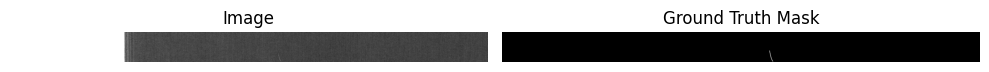

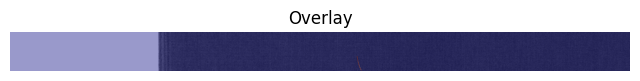

In [40]:
defect_sample = defect_path / '0019_016_03.png'
mask_sample = mask_path / '0019_016_03_mask.png'

image = load_image(defect_sample)
mask = load_mask(mask_sample)

show_mask(image, mask)
show_overlay(image, mask)

## Image Property Verification Across the Full Dataset

#### Checking Image Dimensions
Checking image dimensions across all normal and defective images to confirm consistency.

In [41]:
normal_sizes = Counter()
defect_sizes = Counter()

for image_path in normal_images:
    with Image.open(image_path) as img:
        normal_sizes[img.size] += 1

for image_path in defect_images:
    with Image.open(image_path) as img:
        defect_sizes[img.size] += 1

print("Normal image dimensions:")
for size, count in normal_sizes.items():
    print(size, "→", count, "images")

print("\nDefective image dimensions:")
for size, count in defect_sizes.items():
    print(size, "→", count, "images")

Normal image dimensions:
(4096, 256) → 141 images

Defective image dimensions:
(4096, 256) → 105 images
(3796, 256) → 1 images


#### Resolution Summary Table
Consolidating the width/height range and the set of unique resolutions found across the dataset into a single summary table.

In [42]:
all_widths = [s[0] for s in normal_sizes] + [s[0] for s in defect_sizes]
all_heights = [s[1] for s in normal_sizes] + [s[1] for s in defect_sizes]
unique_resolutions = set(normal_sizes.keys()) | set(defect_sizes.keys())

resolution_summary = pd.DataFrame({
    "Metric": ["Min width", "Max width", "Min height", "Max height", "Unique resolutions"],
    "Value": [min(all_widths), max(all_widths), min(all_heights), max(all_heights), len(unique_resolutions)]
})

resolution_summary

,Metric,Value
0,Min width,3796
1,Max width,4096
2,Min height,256
3,Max height,256
4,Unique resolutions,2


#### Checking Image Color Mode
Checking the color mode across all normal and defective images.

In [43]:
from collections import Counter

normal_modes = Counter()
defect_modes = Counter()

for image_path in normal_images:
    with Image.open(image_path) as img:
        normal_modes[img.mode] += 1

for image_path in defect_images:
    with Image.open(image_path) as img:
        defect_modes[img.mode] += 1

print("Normal image modes:")
print(normal_modes)

print("\nDefective image modes:")
print(defect_modes)

Normal image modes:
Counter({'L': 121, 'LA': 20})

Defective image modes:
Counter({'L': 95, 'LA': 11})


#### Computing Pixel Intensity Statistics
Computing per-image pixel intensity statistics (minimum, maximum, mean, standard deviation) for a subset of images.

In [44]:
import numpy as np

sample_images = normal_images[:10] + defect_images[:10]

for image_path in sample_images:

    image = np.array(Image.open(image_path))

    print(
        image_path.name,
        " | Min:", image.min(),
        " | Max:", image.max(),
        " | Mean:", round(image.mean(), 2),
        " | Std:", round(image.std(), 2)
    )

0003_000_06.png  | Min: 54  | Max: 255  | Mean: 128.29  | Std: 23.59
0001_000_06.png  | Min: 63  | Max: 255  | Mean: 127.19  | Std: 22.36
0002_000_06.png  | Min: 59  | Max: 255  | Mean: 128.47  | Std: 23.48
0008_000_06.png  | Min: 60  | Max: 255  | Mean: 128.18  | Std: 21.07
0020_000_06.png  | Min: 58  | Max: 255  | Mean: 127.98  | Std: 21.09
0006_000_06.png  | Min: 61  | Max: 255  | Mean: 128.73  | Std: 22.21
0010_000_06.png  | Min: 71  | Max: 255  | Mean: 127.19  | Std: 20.32
0007_000_06.png  | Min: 62  | Max: 255  | Mean: 128.92  | Std: 22.71
0013_000_06.png  | Min: 57  | Max: 255  | Mean: 128.3  | Std: 24.32
0009_000_06.png  | Min: 57  | Max: 255  | Mean: 127.34  | Std: 20.68
0043_019_04.png  | Min: 48  | Max: 255  | Mean: 190.84  | Std: 65.64
0041_019_02.png  | Min: 59  | Max: 255  | Mean: 126.72  | Std: 33.25
0042_019_02.png  | Min: 58  | Max: 255  | Mean: 128.18  | Std: 32.67
0074_010_03.png  | Min: 26  | Max: 255  | Mean: 127.89  | Std: 78.24
0060_022_06.png  | Min: 60  | Max: 

#### Pixel Intensity Histogram — Normal Image

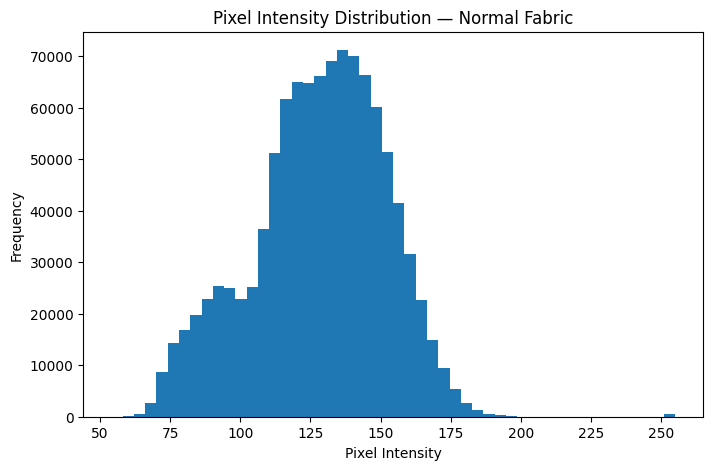

In [45]:
image = np.array(Image.open(normal_images[0]))

plt.figure(figsize=(8, 5))

plt.hist(image.ravel(), bins=50)

plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Pixel Intensity Distribution — Normal Fabric")

plt.show()

#### Comparing Normal and Defective Intensity Histograms

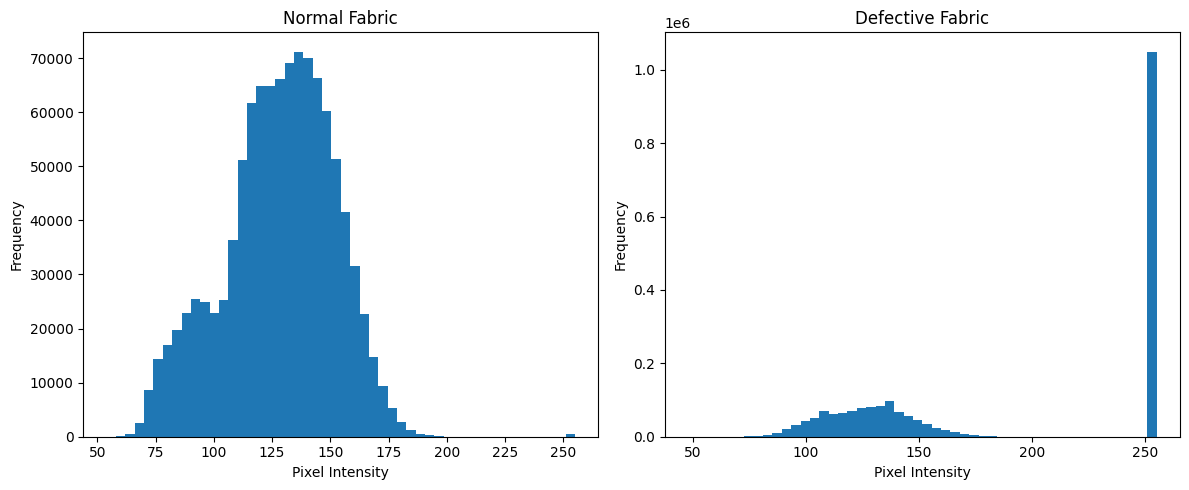

In [46]:
normal_array = np.array(Image.open(normal_images[0]))
defect_array = np.array(Image.open(defect_images[0]))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(normal_array.ravel(), bins=50)
plt.title("Normal Fabric")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(defect_array.ravel(), bins=50)
plt.title("Defective Fabric")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Dataset Summary So Far

In [47]:
print("Dataset Summary")
print("----------------")
print("Normal images    :", len(normal_images))
print("Defective images :", len(defect_images))
print("Total images     :", len(normal_images) + len(defect_images))
print("Mask files       :", len(mask_files))

Dataset Summary
----------------
Normal images    : 141
Defective images : 106
Total images     : 247
Mask files       : 107


#### Defect Type Distribution (Bar Chart)

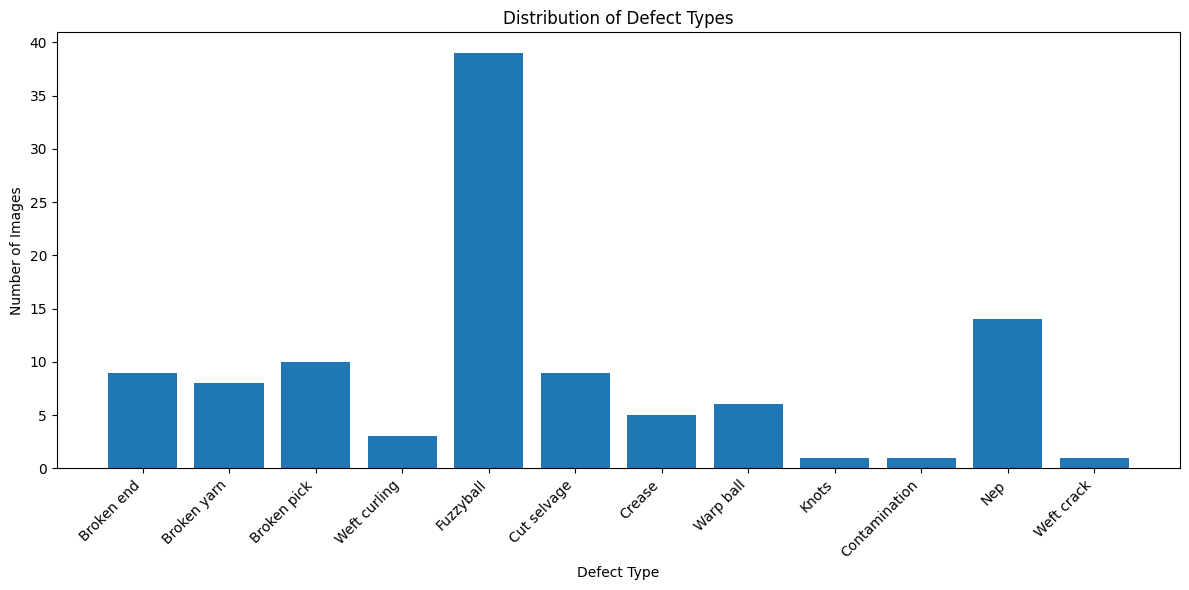

In [48]:
import matplotlib.pyplot as plt

codes = sorted(defect_counter.keys())

names = [defect_codes[code] for code in codes]
counts = [defect_counter[code] for code in codes]

plt.figure(figsize=(12, 6))

plt.bar(names, counts)

plt.xlabel("Defect Type")
plt.ylabel("Number of Images")
plt.title("Distribution of Defect Types")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

#### Defective Images by Fabric Type (Bar Chart)

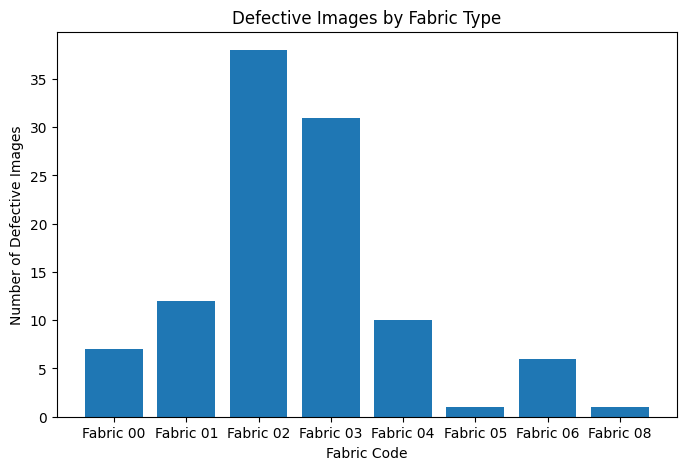

In [49]:
fabric_codes = sorted(fabric_counter.keys())
fabric_counts = [fabric_counter[code] for code in fabric_codes]

plt.figure(figsize=(8, 5))

plt.bar(
    [f"Fabric {code:02d}" for code in fabric_codes],
    fabric_counts
)

plt.xlabel("Fabric Code")
plt.ylabel("Number of Defective Images")
plt.title("Defective Images by Fabric Type")

plt.show()

## Defect Area Analysis

#### Defining the Defect Area Function
Defining a function to compute the percentage of defect area in a given mask file. The mask is loaded through `load_mask()`, so it is always treated as single-channel regardless of how the file is stored.

In [50]:
def calculate_defect_percentage(mask_file):
    """Return the percentage of pixels in a mask that belong to the defect region."""
    mask = np.array(load_mask(mask_file))

    defect_pixels = np.count_nonzero(mask)
    total_pixels = mask.size

    return (defect_pixels / total_pixels) * 100

#### Testing the Function on One Mask

In [51]:
example_mask = mask_files[0]

percentage = calculate_defect_percentage(example_mask)

print("Mask:", example_mask.name)
print("Defect area:", round(percentage, 4), "%")

Mask: 0001_002_00_mask.png
Defect area: 0.133 %


#### Defect Area Statistics Across All Masks

In [52]:
defect_areas = [calculate_defect_percentage(mask_file) for mask_file in mask_files]

print("Number of masks analyzed:", len(defect_areas))
print("Minimum defect area:", round(min(defect_areas), 4), "%")
print("Maximum defect area:", round(max(defect_areas), 4), "%")
print("Average defect area:", round(np.mean(defect_areas), 4), "%")
print("Median defect area:", round(np.median(defect_areas), 4), "%")

Number of masks analyzed: 107
Minimum defect area: 0.0 %
Maximum defect area: 22.2682 %
Average defect area: 0.4364 %
Median defect area: 0.0087 %


#### Defect Area Distribution (Histogram)

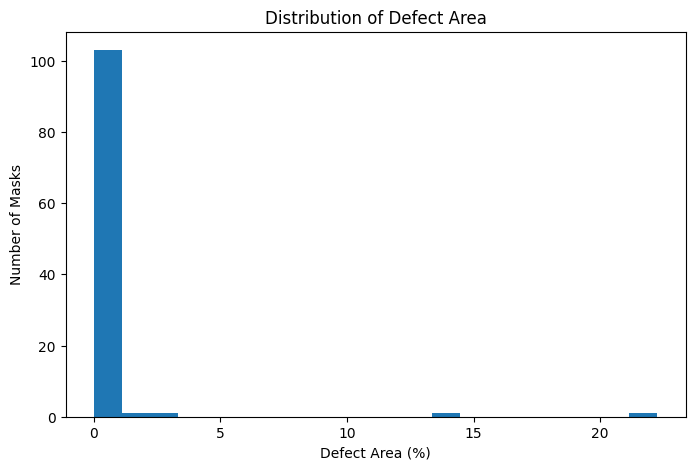

In [53]:
plt.figure(figsize=(8, 5))

plt.hist(defect_areas, bins=20)

plt.xlabel("Defect Area (%)")
plt.ylabel("Number of Masks")
plt.title("Distribution of Defect Area")

plt.show()

#### Identifying Smallest and Largest Defects

In [54]:
min_index = np.argmin(defect_areas)
max_index = np.argmax(defect_areas)

print("Smallest defect:")
print(mask_files[min_index].name)
print(round(defect_areas[min_index], 4), "%")

print("\nLargest defect:")
print(mask_files[max_index].name)
print(round(defect_areas[max_index], 4), "%")

Smallest defect:
0106_010_03_mask.png
0.0 %

Largest defect:
0080_036_01_mask.png
22.2682 %


#### Fabric-Wise Defect Area Statistics
Since the project's adaptive multi-scale approach depends on fabric-specific behaviour, defect area percentages are grouped by fabric code (parsed from each mask's filename) to see whether average defect size varies across fabric types. This uses only masks whose filenames follow the standard `nnnn_ddd_ff` convention (multi-defect masks with a `_mask1`/`_mask2` suffix are excluded from this grouping since their filename does not end in a clean fabric code).

In [55]:
fabric_defect_areas = defaultdict(list)

for mask_file, area in zip(mask_files, defect_areas):
    parts = mask_file.stem.replace('_mask', '').split('_')
    if len(parts) == 3 and parts[2].isdigit():
        fabric_code = int(parts[2])
        fabric_defect_areas[fabric_code].append(area)

fabric_area_summary = pd.DataFrame({
    "Fabric Code": sorted(fabric_defect_areas.keys()),
    "Mask Count": [len(fabric_defect_areas[f]) for f in sorted(fabric_defect_areas.keys())],
    "Mean Defect Area (%)": [round(np.mean(fabric_defect_areas[f]), 4) for f in sorted(fabric_defect_areas.keys())],
    "Max Defect Area (%)": [round(np.max(fabric_defect_areas[f]), 4) for f in sorted(fabric_defect_areas.keys())],
})

fabric_area_summary

,Fabric Code,Mask Count,Mean Defect Area (%),Max Defect Area (%)
0,0,7,0.0622,0.1330
1,1,12,1.9211,22.2682
2,2,38,0.0415,0.2265
3,3,30,0.7022,13.6585
4,4,9,0.0503,0.3889
5,5,1,0.0273,0.0273
6,6,6,0.0112,0.0311
7,31,1,0.0031,0.0031
8,32,1,0.0051,0.0051
9,41,1,0.0040,0.0040


## EDA Summary

#### Consolidated Summary Table
Consolidated summary table of key dataset statistics collected in this notebook.

In [56]:
eda_summary = pd.DataFrame({
    "Category": [
        "Normal Images",
        "Defective Images",
        "Mask Files",
        "Fabric Types",
        "Defect Types"
    ],
    "Value": [
        len(normal_images),
        len(defect_images),
        len(mask_files),
        len(fabric_counter),
        len(defect_counter)
    ]
})

eda_summary

,Category,Value
0,Normal Images,141
1,Defective Images,106
2,Mask Files,107
3,Fabric Types,8
4,Defect Types,12
